In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 日本語フォント設定（Windowsの場合）
plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Yu Gothic', 'Meiryo']
plt.rcParams['axes.unicode_minus'] = False

# 表示設定
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# データディレクトリ
data_dir = r"c:\Users\mikku\OneDrive\デスクトップ\機械学習のお勉強\003Kaggle\Diabates-Prediction\data"

In [2]:
# データの読み込み
train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print("\nFirst 5 rows:")
train.columns

Train shape: (700000, 26)
Test shape: (300000, 25)

First 5 rows:


Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

## Feature Descriptions

| Feature | Description | Type |
|---------|-------------|------|
| **id** | 一意の識別子 | Integer |
| **age** | 年齢（歳） | Integer |
| **alcohol_consumption_per_week** | 週間アルコール消費量 | Integer |
| **physical_activity_minutes_per_week** | 週間運動時間（分） | Integer |
| **diet_score** | 食事スコア（0-10） | Float |
| **sleep_hours_per_day** | 睡眠時間（時間/日） | Float |
| **screen_time_hours_per_day** | スクリーンタイム（時間/日） | Float |
| **bmi** | BMI（体格指数） | Float |
| **waist_to_hip_ratio** | ウエスト・ヒップ比 | Float |
| **systolic_bp** | 収縮期血圧（mmHg） | Integer |
| **diastolic_bp** | 拡張期血圧（mmHg） | Integer |
| **heart_rate** | 心拍数（bpm） | Integer |
| **cholesterol_total** | 総コレステロール（mg/dL） | Integer |
| **hdl_cholesterol** | HDLコレステロール（善玉） | Integer |
| **ldl_cholesterol** | LDLコレステロール（悪玉） | Integer |
| **triglycerides** | 中性脂肪（mg/dL） | Integer |
| **gender** | 性別 | Categorical |
| **ethnicity** | 民族 | Categorical |
| **education_level** | 学歴 | Categorical |
| **income_level** | 収入レベル | Categorical |
| **smoking_status** | 喫煙状況 | Categorical |
| **employment_status** | 雇用状況 | Categorical |
| **family_history_diabetes** | 糖尿病家族歴（0/1） | Binary |
| **hypertension_history** | 高血圧歴（0/1） | Binary |
| **cardiovascular_history** | 心血管疾患歴（0/1） | Binary |
| **diagnosed_diabetes** | 糖尿病診断（目的変数: 0/1） | Binary |

**Note:** HbA1c・空腹時血糖値・食後血糖値などの重要指標はKaggleにより削除済み

In [3]:
# 基本統計情報
print("=" * 60)
print("基本統計情報")
print("=" * 60)
train.describe()

基本統計情報


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# データ型と欠損値の確認
print("=" * 60)
print("データ型と欠損値")
print("=" * 60)
info_df = pd.DataFrame({
    'データ型': train.dtypes,
    '欠損値': train.isnull().sum(),
    '欠損率(%)': (train.isnull().sum() / len(train) * 100).round(2)
})
print(info_df)

データ型と欠損値
                                       データ型  欠損値  欠損率(%)
id                                    int64    0     0.0
age                                   int64    0     0.0
alcohol_consumption_per_week          int64    0     0.0
physical_activity_minutes_per_week    int64    0     0.0
diet_score                          float64    0     0.0
sleep_hours_per_day                 float64    0     0.0
screen_time_hours_per_day           float64    0     0.0
bmi                                 float64    0     0.0
waist_to_hip_ratio                  float64    0     0.0
systolic_bp                           int64    0     0.0
diastolic_bp                          int64    0     0.0
heart_rate                            int64    0     0.0
cholesterol_total                     int64    0     0.0
hdl_cholesterol                       int64    0     0.0
ldl_cholesterol                       int64    0     0.0
triglycerides                         int64    0     0.0
gender                

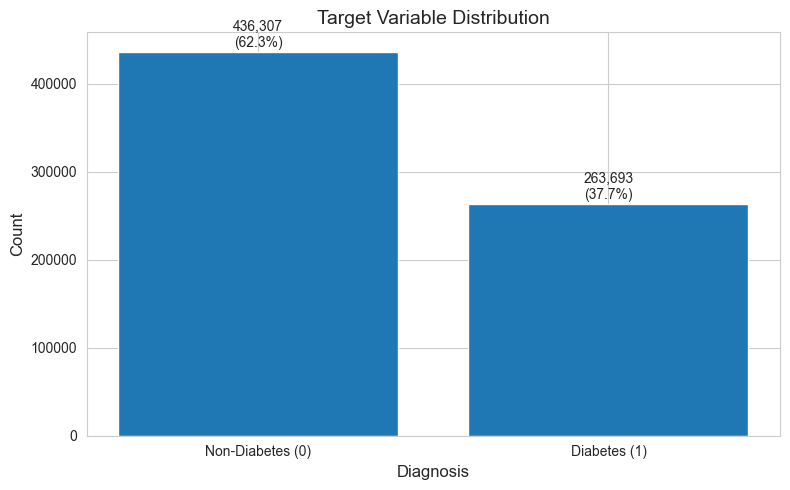


Diabetes rate: 62.33%


In [5]:
# Target variable distribution
plt.figure(figsize=(8, 5))
target_counts = train['diagnosed_diabetes'].value_counts()
plt.bar(['Non-Diabetes (0)', 'Diabetes (1)'], target_counts.values)
plt.title('Target Variable Distribution', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Diagnosis', fontsize=12)

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 5000, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

print(f"\nDiabetes rate: {train['diagnosed_diabetes'].mean():.2%}")

In [6]:
# データ変換
#log1p変換
train['physical_activity_minutes_per_week_log1p'] = np.log1p(train['physical_activity_minutes_per_week'])
test['physical_activity_minutes_per_week_log1p'] = np.log1p(test['physical_activity_minutes_per_week'])

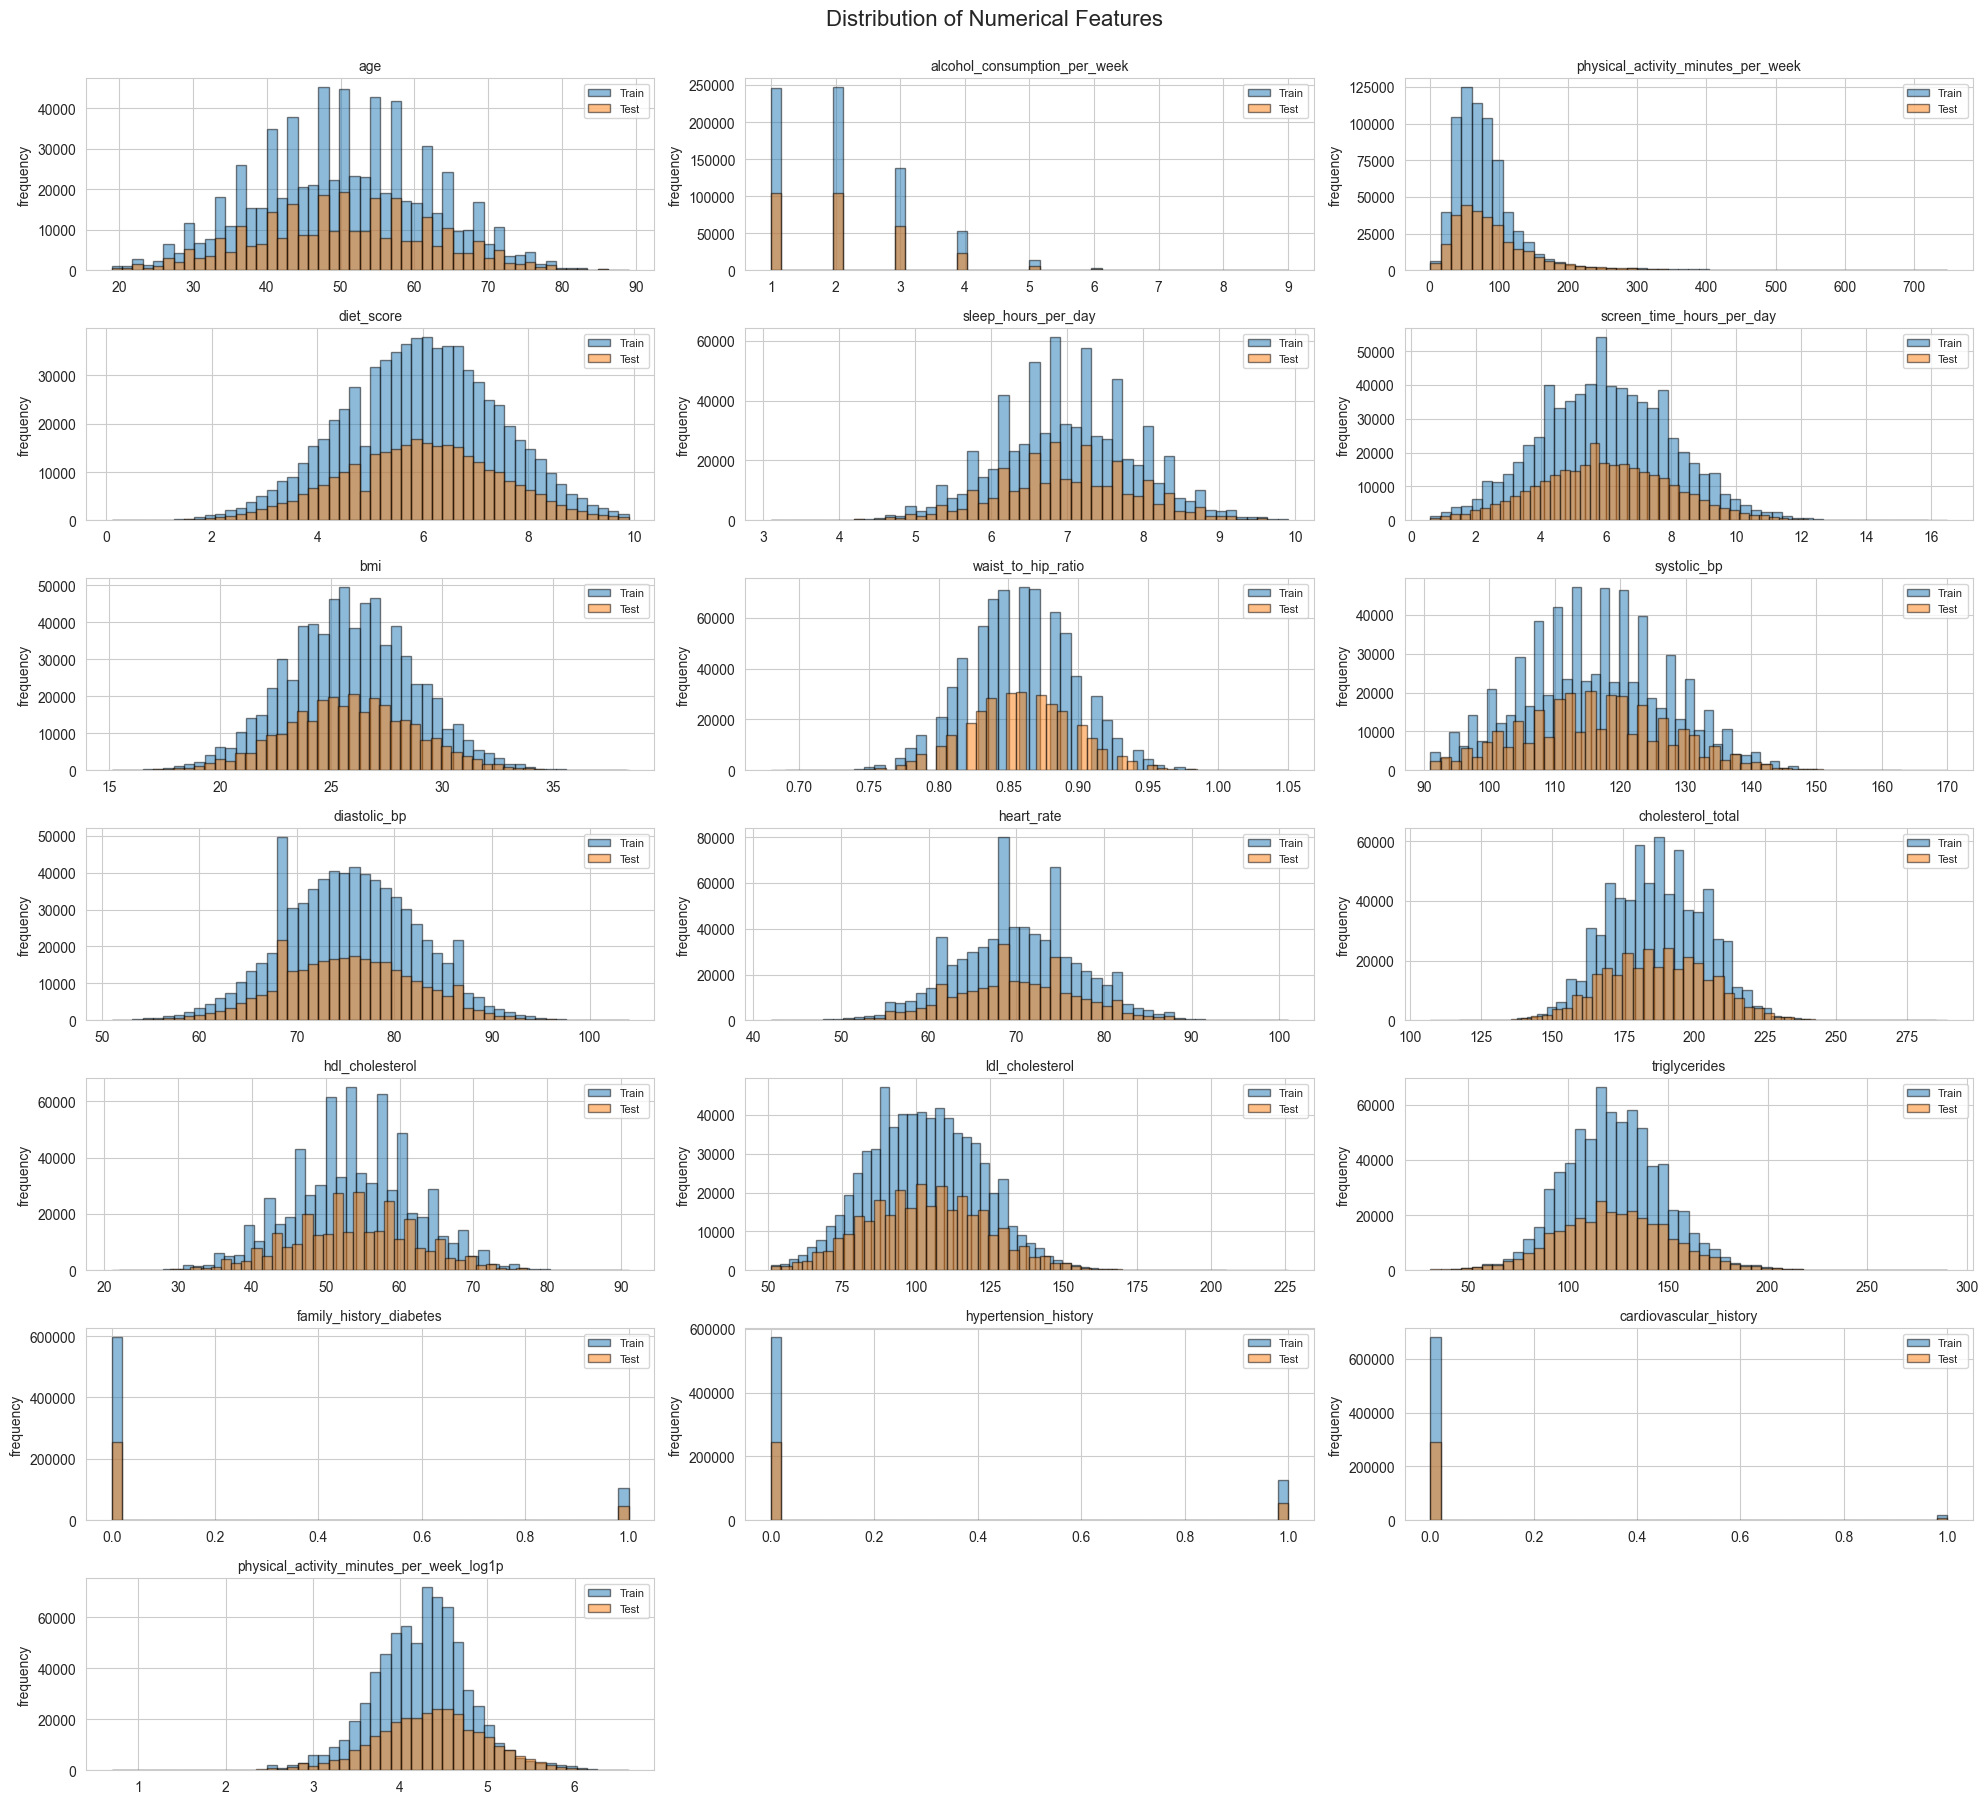

In [7]:
# 数値特徴量の分布（ヒストグラム）
numeric_cols = train.select_dtypes(include=[np.number]).columns.drop(['id', 'diagnosed_diabetes'])
#testデータも追加
numeric_cols_test = test.select_dtypes(include=[np.number]).columns.drop(['id'])

fig, axes = plt.subplots(7, 3, figsize=(20, 18))
axes = axes.ravel()

# testデータも含めてヒストグラムを作成
for idx, col in enumerate(numeric_cols):
    axes[idx].hist(train[col], bins=50, edgecolor='black', alpha=0.5, label='Train')
    axes[idx].hist(test[col], bins=50, edgecolor='black', alpha=0.5, label='Test')
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('frequency')
    axes[idx].legend(fontsize=8)

# 余ったサブプロットを非表示
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

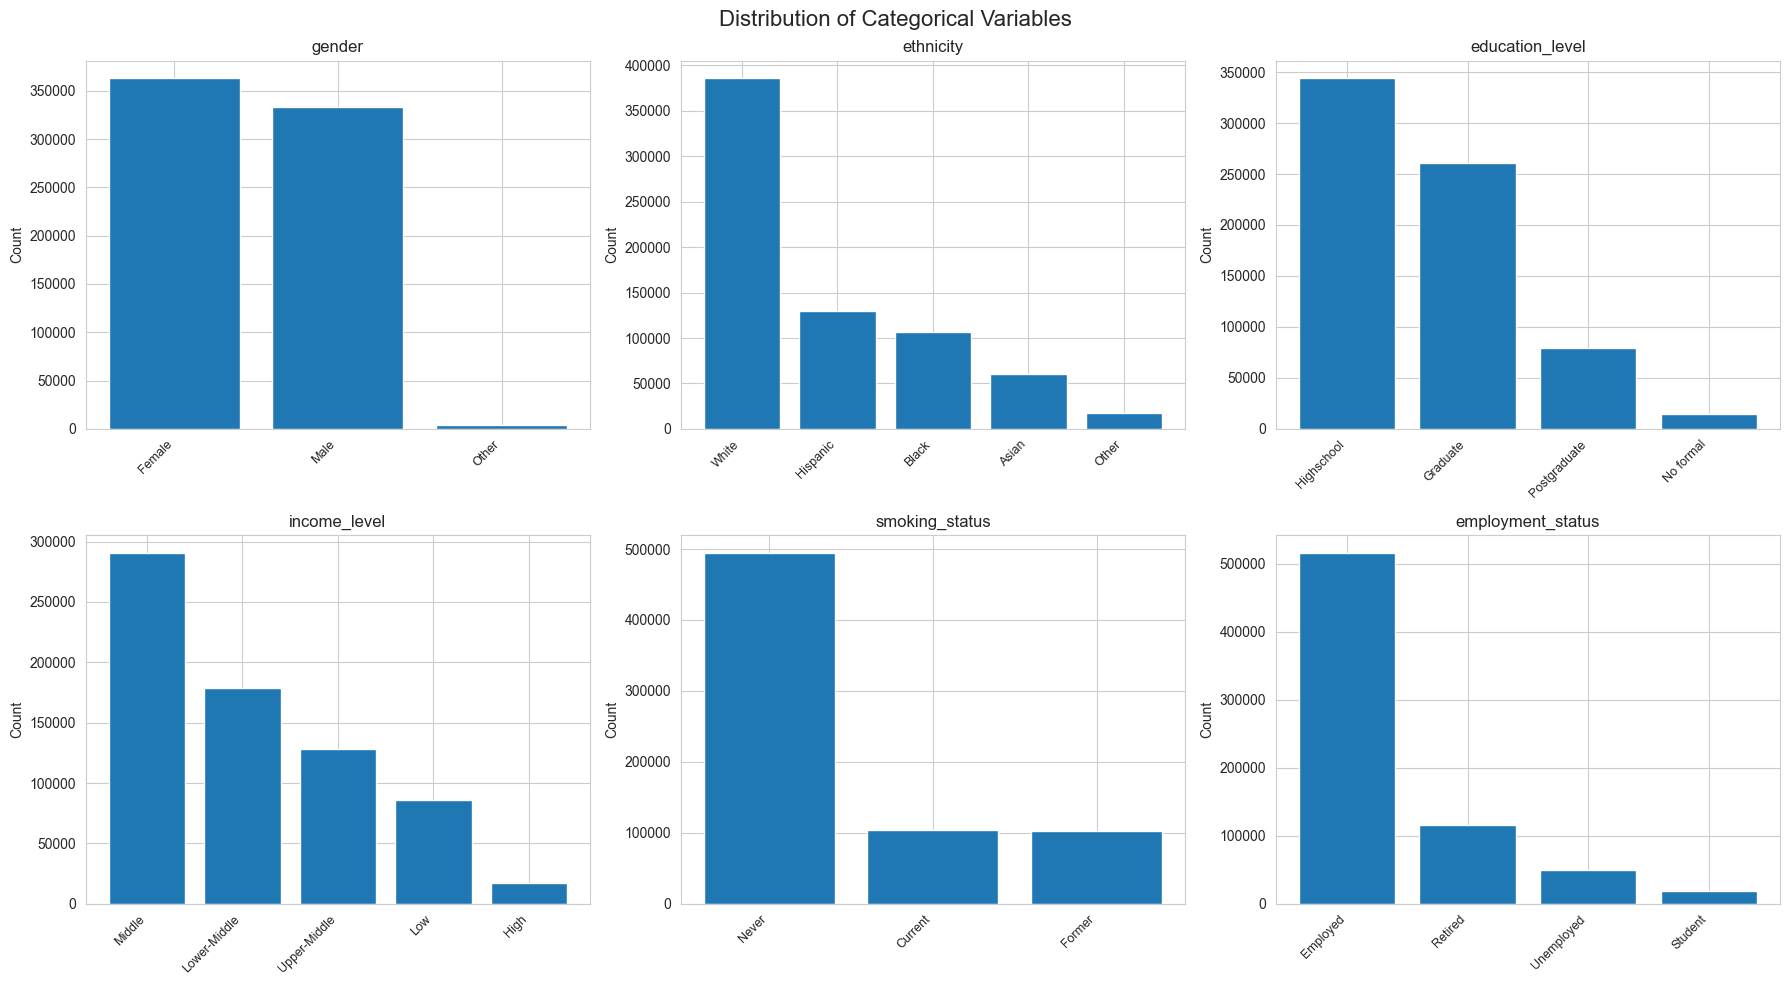

In [8]:
# Categorical variable distribution
categorical_cols = ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    value_counts = train[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values)
    axes[idx].set_title(col, fontsize=12)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel('Count')

plt.suptitle('Distribution of Categorical Variables', fontsize=16)
plt.tight_layout()
plt.show()

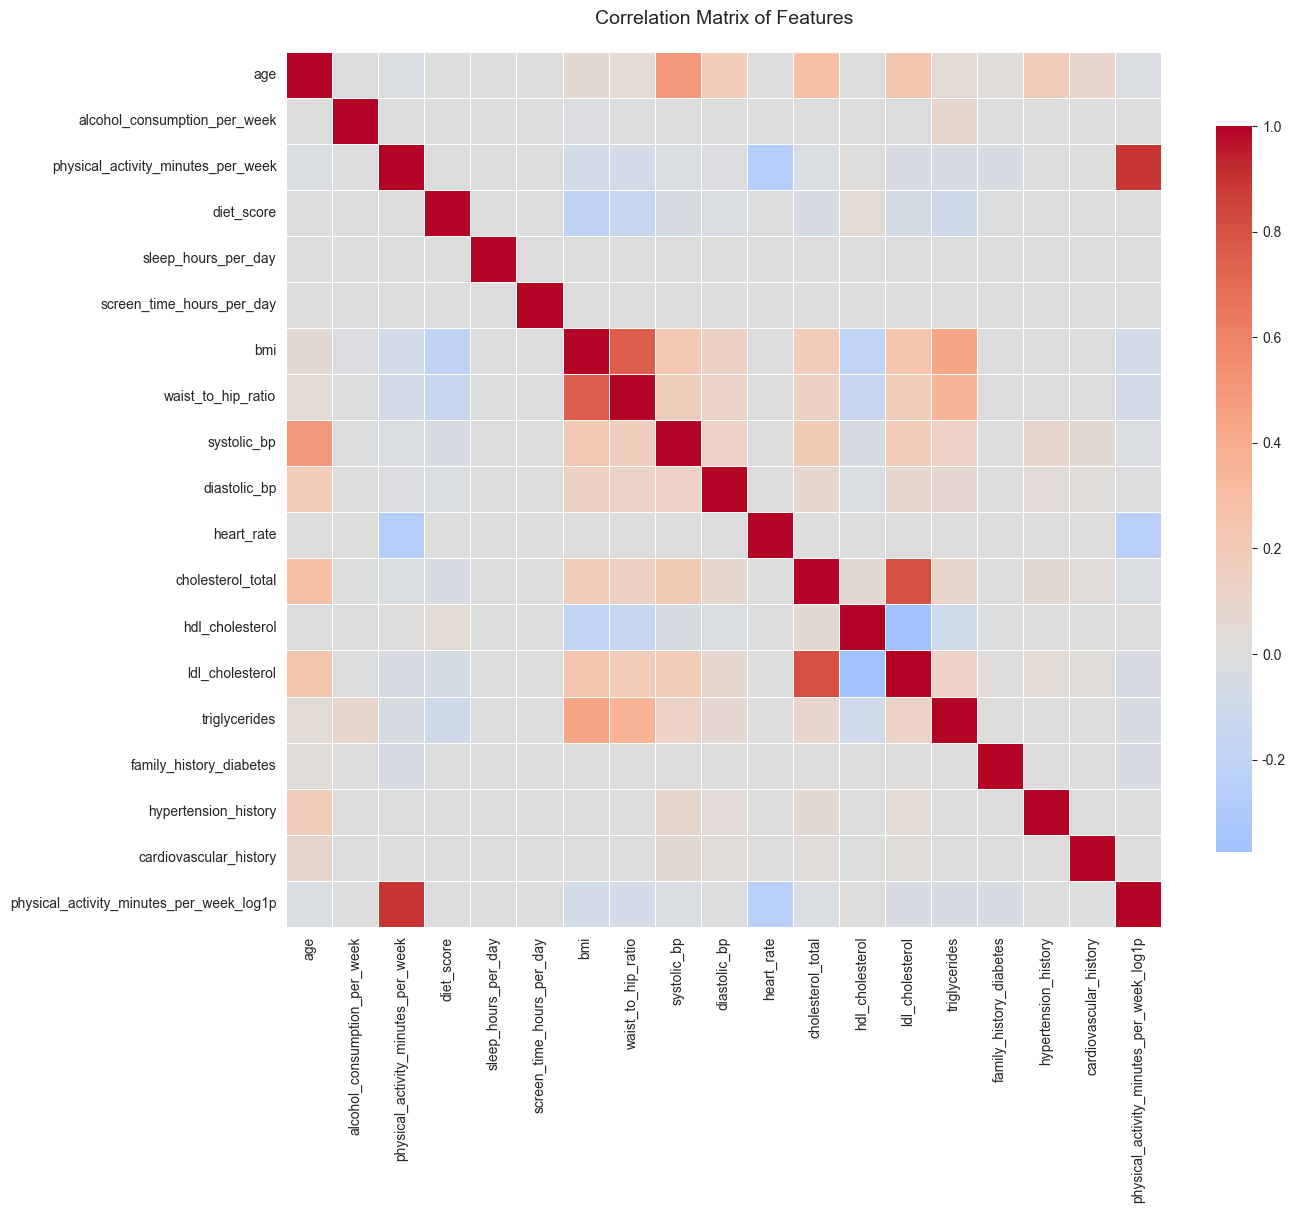


Highly correlated pairs (|r| > 0.7):
physical_activity_minutes_per_week <-> physical_activity_minutes_per_week_log1p: 0.895
bmi <-> waist_to_hip_ratio: 0.757
cholesterol_total <-> ldl_cholesterol: 0.806


In [9]:
# Correlation matrix (numerical features only)
plt.figure(figsize=(14, 12))
correlation = train[numeric_cols].corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Display highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.7):")
high_corr = []
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        if abs(correlation.iloc[i, j]) > 0.7:
            high_corr.append((correlation.columns[i], correlation.columns[j], correlation.iloc[i, j]))

if high_corr:
    for col1, col2, corr_val in high_corr:
        print(f"{col1} <-> {col2}: {corr_val:.3f}")
else:
    print("None found")

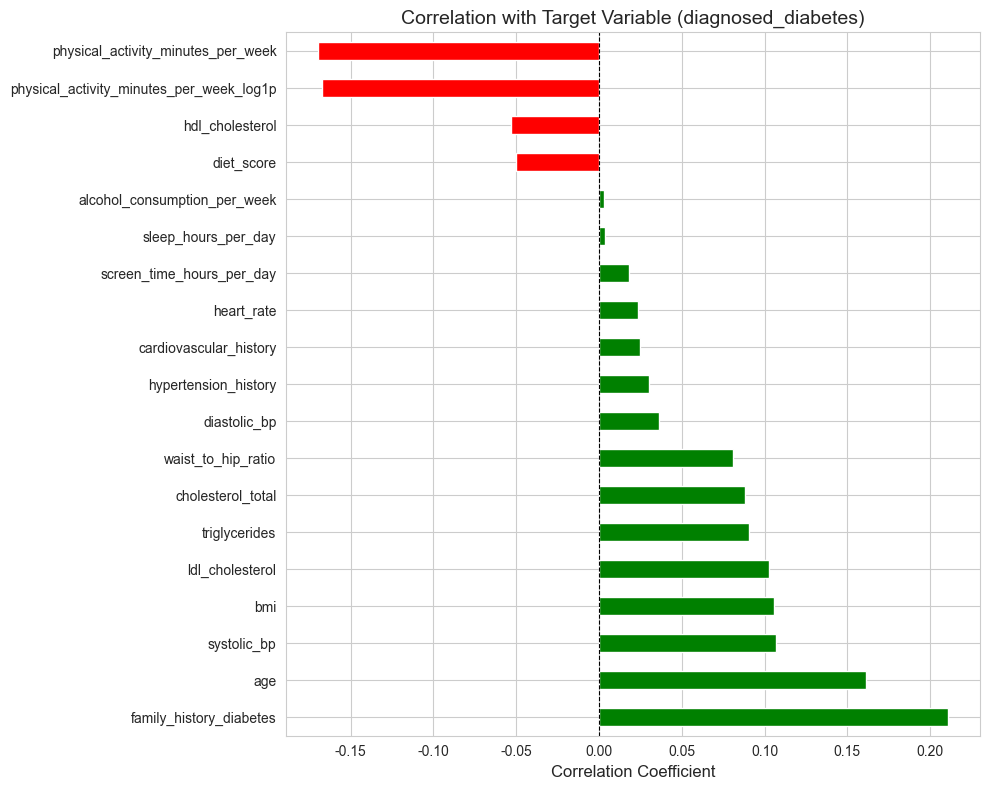


Top features correlated with target:
family_history_diabetes    0.211064
age                        0.161162
systolic_bp                0.107132
bmi                        0.105580
ldl_cholesterol            0.102771
triglycerides              0.090635
cholesterol_total          0.088112
waist_to_hip_ratio         0.081050
diastolic_bp               0.036271
hypertension_history       0.029979
dtype: float64


In [10]:
# Correlation with target (numerical features)
target_corr = train[numeric_cols].corrwith(train['diagnosed_diabetes']).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_corr])
plt.title('Correlation with Target Variable (diagnosed_diabetes)', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop features correlated with target:")
print(target_corr.head(10))

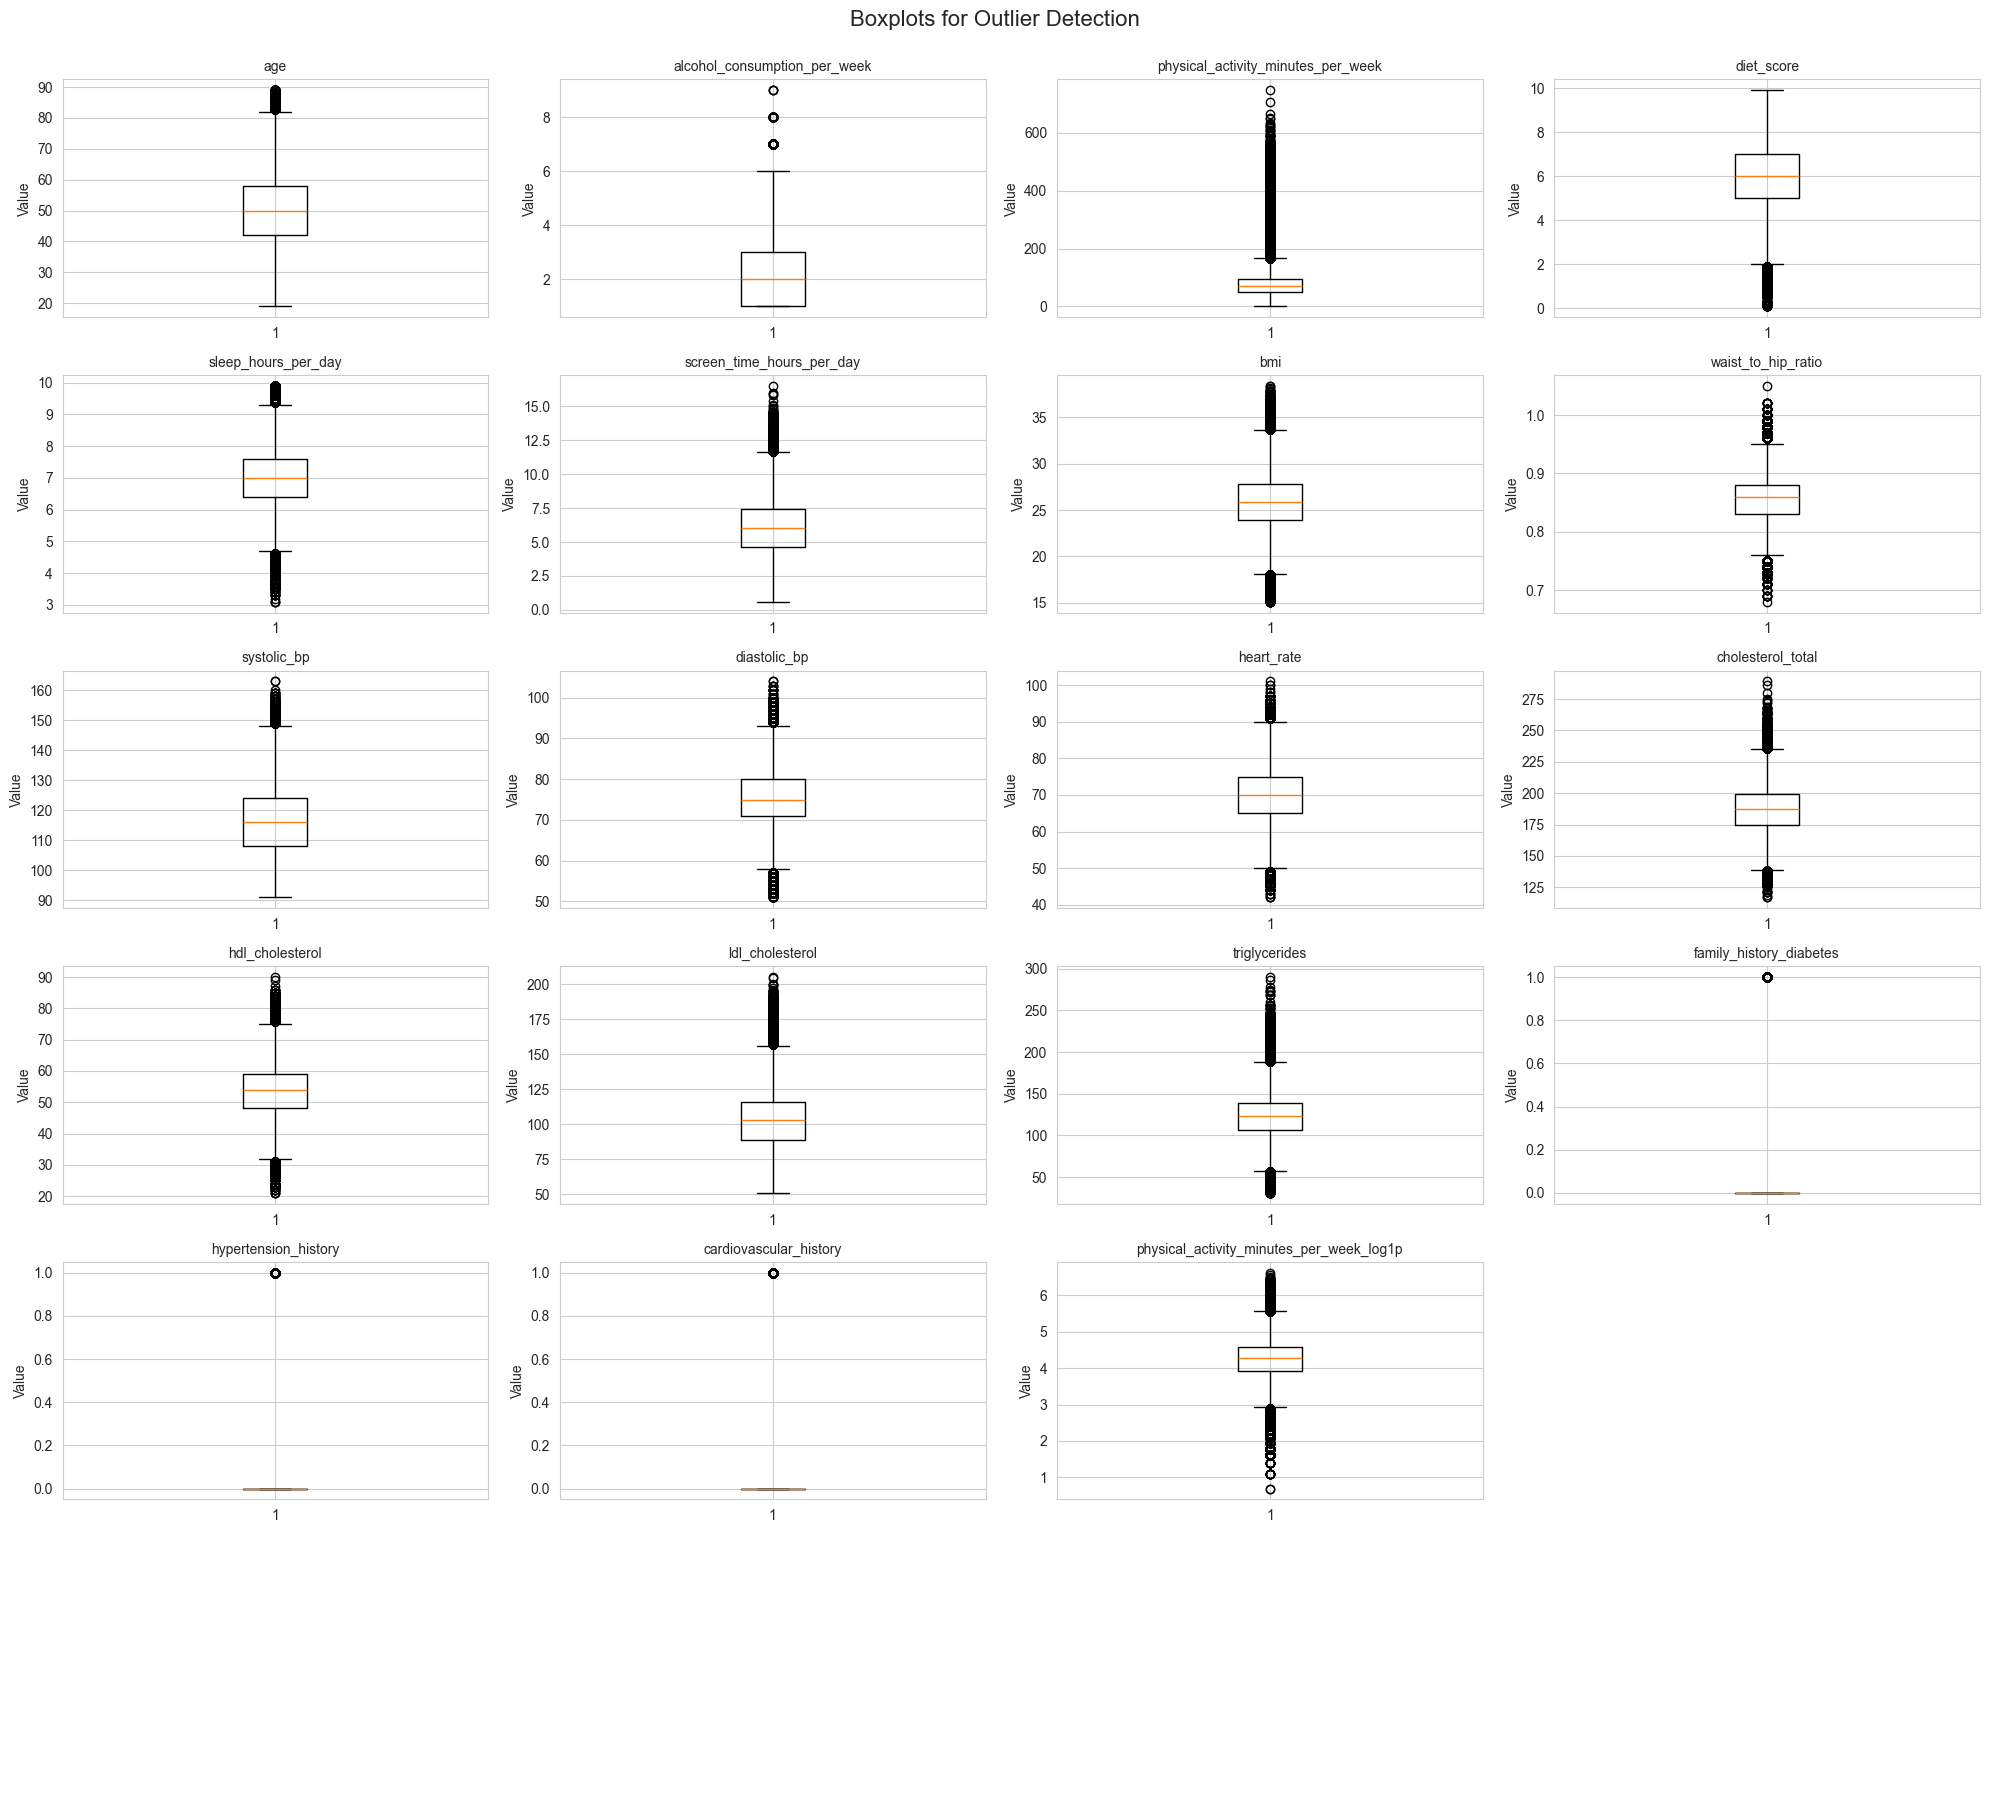

In [11]:
# Outlier detection (boxplot)
fig, axes = plt.subplots(6, 4, figsize=(20, 18))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(train[col].dropna(), vert=True)
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_ylabel('Value')

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

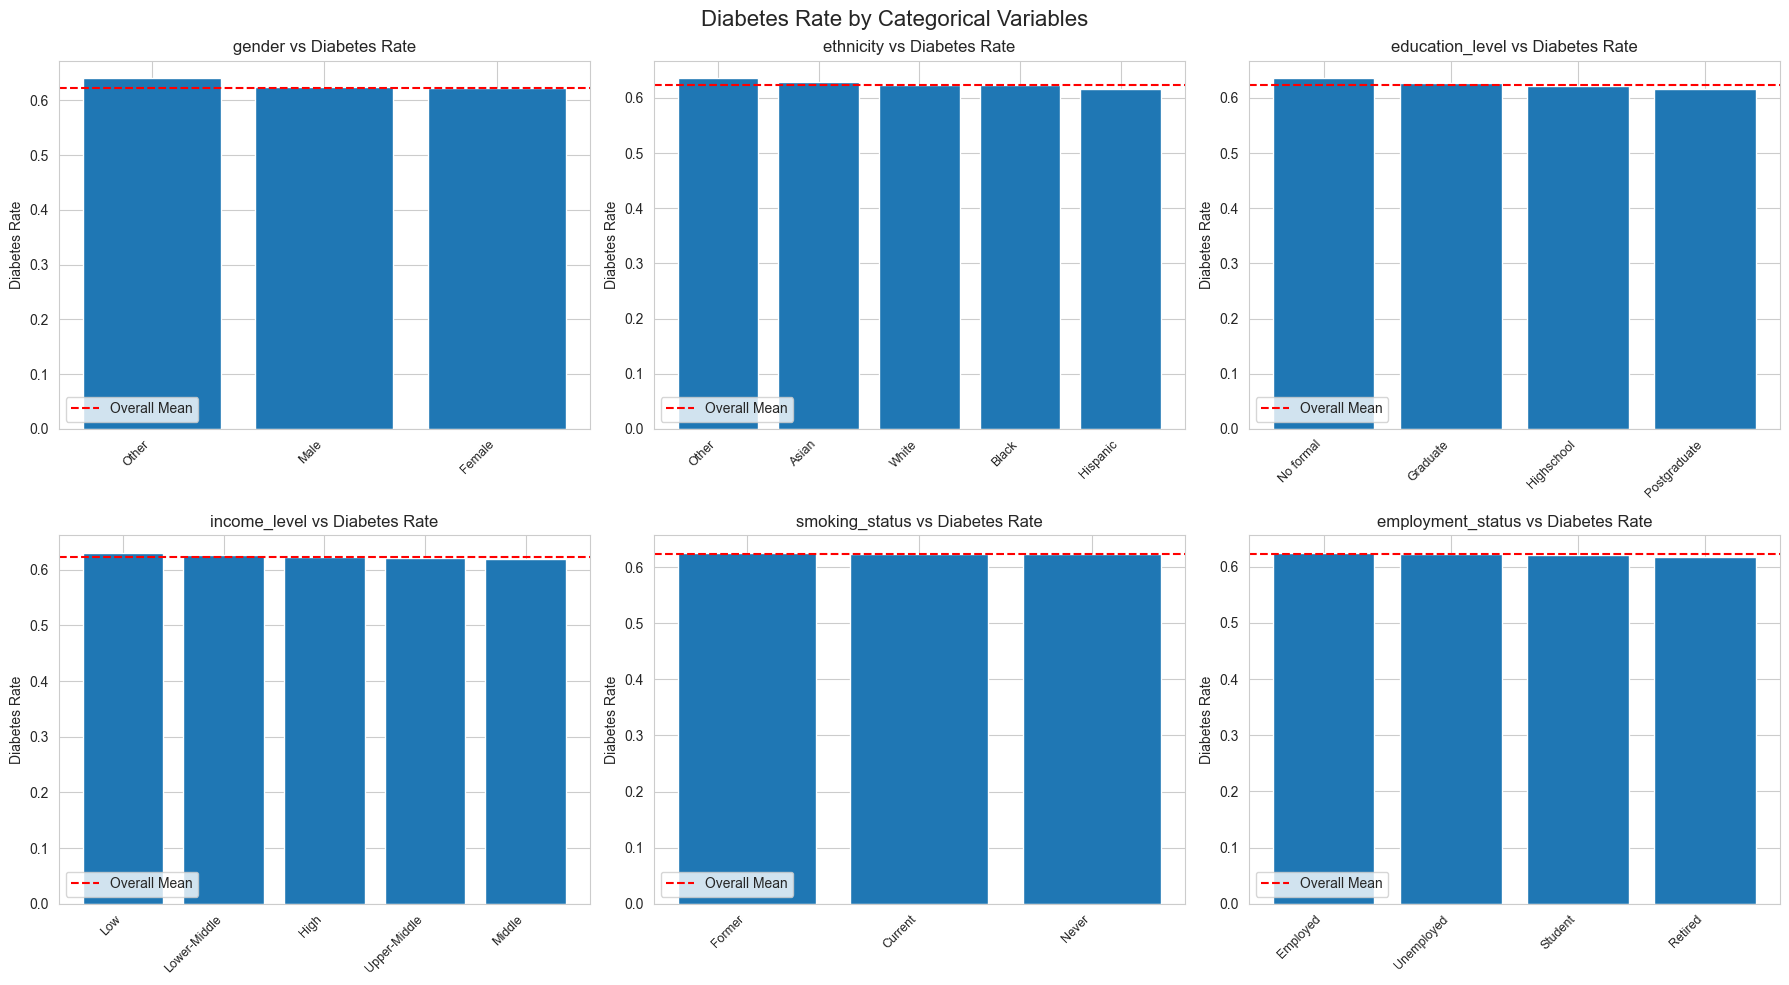

In [12]:
# Relationship between categorical variables and target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    diabetes_rate = train.groupby(col)['diagnosed_diabetes'].mean().sort_values(ascending=False)
    axes[idx].bar(range(len(diabetes_rate)), diabetes_rate.values)
    axes[idx].set_title(f'{col} vs Diabetes Rate', fontsize=12)
    axes[idx].set_xticks(range(len(diabetes_rate)))
    axes[idx].set_xticklabels(diabetes_rate.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel('Diabetes Rate')
    axes[idx].axhline(y=train['diagnosed_diabetes'].mean(), color='red', linestyle='--', label='Overall Mean')
    axes[idx].legend()

plt.suptitle('Diabetes Rate by Categorical Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Encode categorical variables
train_model = train.copy()
categorical_cols = ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']

for col in categorical_cols:
    le = LabelEncoder()
    train_model[col] = le.fit_transform(train_model[col])

# Prepare X and y
X = train_model.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train_model['diagnosed_diabetes']

# Train/Val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Class distribution in training: {y_train.value_counts(normalize=True).to_dict()}")

X_train: (560000, 25), X_val: (140000, 25)
Class distribution in training: {1.0: 0.6232964285714285, 0.0: 0.3767035714285714}


In [14]:
# Test 3 simple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'AUC-ROC': auc
    })
    
    print(f"{name} - Accuracy: {acc:.4f}, AUC-ROC: {auc:.4f}")

# Summary table
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("Baseline Model Comparison")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)


Training Logistic Regression...


c:\Users\mikku\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - Accuracy: 0.6634, AUC-ROC: 0.6948

Training Random Forest...
Random Forest - Accuracy: 0.6668, AUC-ROC: 0.7017

Training XGBoost...
XGBoost - Accuracy: 0.6796, AUC-ROC: 0.7197

Baseline Model Comparison
              Model  Accuracy  AUC-ROC
Logistic Regression  0.663414 0.694759
      Random Forest  0.666771 0.701728
            XGBoost  0.679621 0.719724


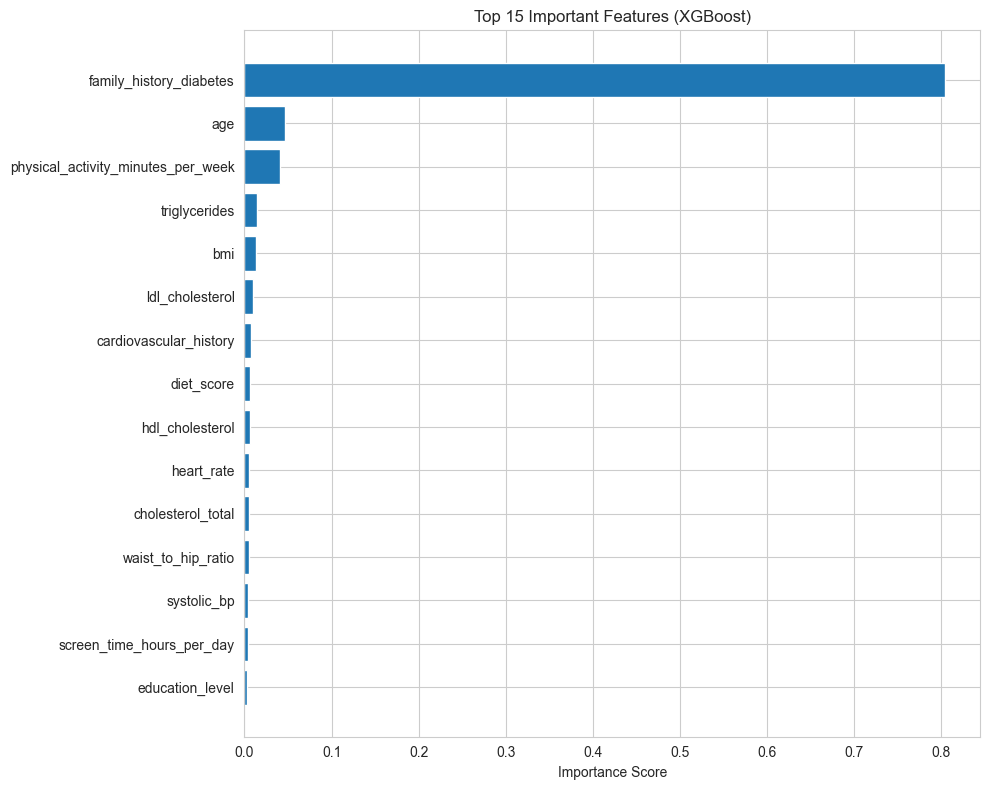


Top 10 Important Features:
                           Feature  Importance
           family_history_diabetes    0.804069
                               age    0.047076
physical_activity_minutes_per_week    0.040947
                     triglycerides    0.014438
                               bmi    0.013005
                   ldl_cholesterol    0.010225
            cardiovascular_history    0.007107
                        diet_score    0.006821
                   hdl_cholesterol    0.006366
                        heart_rate    0.005479


In [15]:
# Feature importance from best model (XGBoost)
best_model = models['XGBoost']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 important features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 15 Important Features (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))